# VisXAI: Graph (PyTorch Geometric) Path Demo

This is the third and final paradigm demo, alongside `tree_demo.ipynb`
(fingerprints + SHAP) and `sequence_demo.ipynb` (tokens + attention). The
pipeline here is:

`generate_graph_representation` (SMILES → node/edge features) →
`PyTorchGNNWrapper` (wraps a trained GNN) →
`IntegratedGradientsExplainer` **and** `GradCAMExplainer` (two different
graph XAI algorithms) → `RDKitSVGVisualizer` (the same 2D renderer used by
every other path, unchanged).

Like `sequence_demo.ipynb`, the model here is **actually trained** via
real gradient descent — not left at random untrained weights the way the
unit tests use it (those only need to check the explainer math, not learn
anything real).


In [1]:
import torch
from IPython.display import SVG, display
from torch_geometric.data import Batch
from torch_geometric.nn import global_mean_pool

from visxai.core.data_types import Explanation
from visxai.explainers.gradient_based import GradCAMExplainer, IntegratedGradientsExplainer
from visxai.features.graphs import generate_graph_representation
from visxai.models.pytorch_wrapper import PyTorchGNNWrapper
from visxai.visualizers.rdkit_2d import RDKitSVGVisualizer


## The dataset

Same synthetic task as `sequence_demo.ipynb`: **does this molecule
contain an aromatic ring?** (`any(atom.GetIsAromatic() for atom in
mol.GetAtoms())`, computed directly by RDKit — no external data.) Reusing
the exact same 12-molecule set and label lets this demo be read as "same
task, third paradigm" rather than introducing a new dataset to reason
about.

The set is balanced (6 aromatic / 6 non-aromatic) and, critically,
includes `cyclohexane` — a molecule *with* a ring that is *not* aromatic.
Without it, a model could get the task right by learning "contains any
ring" instead of actually detecting aromaticity; `cyclohexane` is the one
molecule that tells the two apart during training.


In [2]:
def atom_featurizer(atom):
    return [atom.GetAtomicNum(), atom.GetDegree()]


def bond_featurizer(bond):
    return [bond.GetBondTypeAsDouble()]


TRAIN_SMILES = {
    "ethanol": "CCO",
    "benzene": "c1ccccc1",
    "acetic_acid": "CC(=O)O",
    "pyrrolidine": "C1CCNC1",
    "aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "pyridine": "c1ccncc1",
    "ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "hexane": "CCCCCC",
    "cyclohexane": "C1CCCCC1",
    "toluene": "Cc1ccccc1",
    "acetamide": "CC(=O)N",
    "naphthalene": "c1ccc2ccccc2c1",
}

mol_reps = {
    name: generate_graph_representation(smiles, atom_featurizer, bond_featurizer)
    for name, smiles in TRAIN_SMILES.items()
}
labels = {
    name: float(any(atom.GetIsAromatic() for atom in rep.mol.GetAtoms()))
    for name, rep in mol_reps.items()
}

n_aromatic = sum(labels.values())
print(f"{int(n_aromatic)}/{len(labels)} aromatic")
for name, label in labels.items():
    print(f"  {name:12s} aromatic={bool(label)}")


6/12 aromatic
  ethanol      aromatic=False
  benzene      aromatic=True
  acetic_acid  aromatic=False
  pyrrolidine  aromatic=False
  aspirin      aromatic=True
  pyridine     aromatic=True
  ibuprofen    aromatic=True
  hexane       aromatic=False
  cyclohexane  aromatic=False
  toluene      aromatic=True
  acetamide    aromatic=False
  naphthalene  aromatic=True


Note what's *not* a feature here: `atom_featurizer` only exposes atomic
number and degree, and `bond_featurizer` only exposes bond order. RDKit's
own `atom.GetIsAromatic()` is deliberately **excluded** — including it
would leak the label directly into the input (every aromatic atom would
trivially self-report), making the explanation meaningless. The model has
to infer aromaticity from atomic-number/degree/bond-order structure
alone, the same way `sequence_demo.ipynb`'s tokenizer never encodes
aromaticity as its own token.


## Model

A small 2-layer message-passing GNN — the `msg_lin`/`node_lin` message-passing pattern (compute a per-directed-edge message from
`concat(x[src], edge_attr)`, aggregate into destination nodes, combine
with a node-only linear transform, ReLU), stacked twice so there's a
real "first layer" vs. "last layer" distinction — `GradCAMExplainer`'s
`target_layer`/`edge_target_layer` choice below points at the *last*
layer, matching the conventional "last conv layer" choice from the
original (image) Grad-CAM paper. It's redefined here rather than
imported since the test class is test-private, the same framing
`sequence_demo.ipynb` used for its attention model.


In [3]:
# A 2-layer hand-rolled message-passing GNN over (x, edge_index, edge_attr, batch).
class TinyMessagePassingGNN(torch.nn.Module):
    def __init__(self, in_dim=2, edge_dim=1, hidden_dim=16, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.msg_lin1 = torch.nn.Linear(in_dim + edge_dim, hidden_dim)
        self.node_lin1 = torch.nn.Linear(in_dim, hidden_dim)
        self.msg_lin2 = torch.nn.Linear(hidden_dim + edge_dim, hidden_dim)
        self.node_lin2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.out_lin = torch.nn.Linear(hidden_dim, 1)

    @staticmethod
    def _message_passing_layer(x, edge_index, edge_attr, msg_lin, node_lin):
        src, dst = edge_index[0], edge_index[1]
        messages = msg_lin(torch.cat([x[src], edge_attr], dim=-1)).relu()
        agg = torch.zeros(x.shape[0], messages.shape[-1], dtype=messages.dtype)
        agg = agg.index_add(0, dst, messages)
        return (node_lin(x) + agg).relu()

    def forward(self, x, edge_index, edge_attr, batch):
        h = self._message_passing_layer(x, edge_index, edge_attr, self.msg_lin1, self.node_lin1)
        h = self._message_passing_layer(h, edge_index, edge_attr, self.msg_lin2, self.node_lin2)
        pooled = global_mean_pool(h, batch)
        return self.out_lin(pooled)


model = TinyMessagePassingGNN()


In [4]:
names = list(TRAIN_SMILES.keys())
train_batch = Batch.from_data_list([mol_reps[name].pyg_data for name in names])
label_tensor = torch.tensor([[labels[name]] for name in names], dtype=torch.float)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = torch.nn.BCEWithLogitsLoss()

model.train()
for epoch in range(150):
    optimizer.zero_grad()
    out = model(train_batch.x, train_batch.edge_index, train_batch.edge_attr, train_batch.batch)
    loss = loss_fn(out, label_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 15 == 0:
        print(f"epoch {epoch:3d}  loss={loss.item():.4f}")
print(f"epoch {epoch:3d}  loss={loss.item():.4f}  (final)")


epoch   0  loss=1.4459
epoch  15  loss=0.6902
epoch  30  loss=0.6133
epoch  45  loss=0.5180
epoch  60  loss=0.3448
epoch  75  loss=0.1725
epoch  90  loss=0.0593
epoch 105  loss=0.0212
epoch 120  loss=0.0102
epoch 135  loss=0.0063
epoch 149  loss=0.0046  (final)


### Sanity check: did the model actually learn anything?

If training worked, predictions should spread out toward 0 or 1 and track
the true labels — and, specifically, `cyclohexane` should come out
*non*-aromatic despite having a ring, confirming the model isn't just
counting rings.


In [5]:
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(
        model(train_batch.x, train_batch.edge_index, train_batch.edge_attr, train_batch.batch)
    )

for name, prob in zip(names, probs.numpy().ravel()):
    print(f"  {name:12s} P(aromatic)={prob:.3f}  true={labels[name]}")


  ethanol      P(aromatic)=0.000  true=0.0
  benzene      P(aromatic)=0.995  true=1.0
  acetic_acid  P(aromatic)=0.001  true=0.0
  pyrrolidine  P(aromatic)=0.007  true=0.0
  aspirin      P(aromatic)=0.997  true=1.0
  pyridine     P(aromatic)=0.988  true=1.0
  ibuprofen    P(aromatic)=0.997  true=1.0
  hexane       P(aromatic)=0.000  true=0.0
  cyclohexane  P(aromatic)=0.018  true=0.0
  toluene      P(aromatic)=0.998  true=1.0
  acetamide    P(aromatic)=0.002  true=0.0
  naphthalene  P(aromatic)=1.000  true=1.0


## Explaining aspirin with Integrated Gradients

`IntegratedGradientsExplainer` gives **signed** atom scores, and — since
this model consumes `edge_attr` (`PyTorchGNNWrapper(model,
uses_edge_attr=True)`) — **signed bond scores for every bond**, not just
the ones with an explicit SMILES character (contrast with the sequence
path's inherently partial bond coverage).


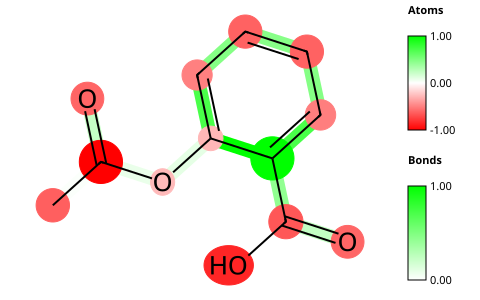

atoms scored: 13 / 13
bonds scored: 13 / 13
metadata: {'n_steps': 50, 'predicted_value': 5.741733551025391, 'attribution': 'graph/direct'}


In [6]:
wrapper = PyTorchGNNWrapper(model, uses_edge_attr=True)
aspirin = mol_reps["aspirin"]

ig_explainer = IntegratedGradientsExplainer()
ig_explanation = ig_explainer.explain(wrapper, aspirin)

visualizer = RDKitSVGVisualizer()
display(SVG(visualizer.visualize(aspirin, ig_explanation)))

print(f"atoms scored: {len(ig_explanation.atom_scores)} / {aspirin.mol.GetNumAtoms()}")
print(f"bonds scored: {len(ig_explanation.bond_scores)} / {aspirin.mol.GetNumBonds()}")
print(f"metadata: {ig_explanation.metadata}")


Red = pushes the prediction down, green = pushes it up, white = neutral —
every atom and every bond gets a real (non-default) value, since node
`i` = atom `i` and every bond has an `edge_attr` vector to differentiate,
regardless of whether it has an explicit character in the SMILES string.


### Why does almost everything look colored, not just the ring?

If this is your first time reading one of these figures: it's normal for
the coloring to look spread across the whole molecule rather than sharply
picked out on just the aromatic ring &mdash; that's not a bug. For
aspirin, IG assigns a **negative score to nearly every atom** and a
**positive score to every bond**. The six aromatic ring bonds *are* the
top-scoring bonds (their distinctive bond order, 1.5, is the strongest
aromaticity signal available to this model), but only by a modest margin
over the rest.

**`RDKitSVGVisualizer` normalizes atom and bond scores on independent
scales by default** (`color_scale="separate"`, with its own "Atoms"/"Bonds"
legend for each) specifically because of a case like this one: aspirin's
IG bond scores (`+0.90` to `+2.08`) are more than ten times larger than its one positive atom score (`+0.16`). Under
`color_scale="combined"` (one shared min/max across every atom *and*
bond), that one positive atom would render at only **`t≈0.07`** &mdash;
barely tinted green, indistinguishable from "no signal" &mdash; purely
because a much larger bond magnitude happens to exist elsewhere in the
same molecule, even though `+0.16` is a real, meaningfully-sized value
*within the atom population itself*. Under the default `"separate"`
scaling that same atom renders at full saturation (`t=1.00`) instead,
since it's judged against the atom population's own range, not the
bond-inflated combined one.

**The color mapping is also sign-aware**, independently of `color_scale`
(see `_score_to_t`'s docstring for the full derivation). Two things this
fixes on this exact figure:

- A score population that has both positive and negative values (the
  atoms here, `-1.38..+0.16`) stays a zero-anchored diverging scale, but
  each side is now scaled to its *own* actual extreme rather than a
  shared symmetric span &mdash; so the one positive atom (`+0.16`, the
  *maximum* positive value that exists) reaches full green, not a muted
  `t≈0.11` capped by the negative side's larger `1.38` swing.
- A score population that's entirely one sign (the bonds here, all
  positive, `+0.90..+2.08`, nowhere near zero) switches to a sequential
  min→max stretch instead of forcing a zero anchor with no data near it.
  The least-positive bond used to render at `t≈0.43` (already fairly
  saturated green) purely because of the unused zero anchor below it,
  making every bond look similarly green; it now renders white
  (`t=0.00`), and the whole bond legend uses its full range.

**Highlighted atom-circle radius also now scales with score magnitude**
(`scale_atom_radius=True`, the default) &mdash; a second visual channel
alongside color, so a magnitude difference stays visible even where two
atoms' colors both land in a similarly-saturated range. Pass
`scale_atom_radius=False` for a uniform circle size on every highlighted
atom.

**One more reading trap: the rendered molecule can look "all green" even
though the Atom legend is mostly red.** Every one of aspirin's 13 bonds
has a positive score here, so the Bonds legend (`0.00`&rarr;`1.00`) is pure
white-to-green with no red at all &mdash; and the thick colored bands
RDKit draws along each bond are visually more prominent than the atom
circles. So a glance at the figure reads as mostly green, even though 12
of the 13 *atoms* are actually red/pink, matching the separate Atoms
legend (`-1.00`&rarr;`1.00`) right next to it. If a color in the figure
doesn't seem to match a legend you're looking at, check whether it's
actually the *other* legend (Atoms vs. Bonds) that color belongs to.

And what the model attributes is still spread across the whole molecule,
for two real, verified-not-buggy reasons (confirmed by checking every
atom/bond's score against RDKit's own `GetIsAromatic()`, and by checking
IG's completeness axiom holds *exactly* &mdash; `sum(atom_scores) +
sum(bond_scores) == predicted_value - baseline_prediction`, not just
asserted):

- **Global mean pooling.** Every atom feeds the pooled prediction equally
  regardless of position, so this tiny model has little structural
  incentive to *localize* its signal onto just the ring, the way an
  attention mechanism (`sequence_demo.ipynb`) naturally does.
- **Integrated Gradients on concatenated atom+edge inputs.** This
  architecture concatenates atom features with edge features before every
  nonlinear layer, so along IG's straight-line integration path, most of
  the credit for "aromatic" lands on the *bond* component (which directly
  carries the distinguishing bond-order value) and a small negative credit
  lands on the atom component almost everywhere &mdash; a known IG
  characteristic for models with strongly-interacting inputs, not a defect
  in the explainer.

Grad-CAM (below) shows a related but distinct pattern: about two thirds of
aspirin's atoms come out exactly `0.0` rather than uniformly negative, but
its nonzero bond scores are still spread across the whole molecule rather
than sharply confined to the ring, for the same underlying (mean-pooling)
reason.


### Raw vs. normalized legend numbers

The legend above prints **normalized** tick labels by default
(`legend_units="normalized"`) — each number is the exact same value `t`
that already determines that tick's color, so the number and the color
can never visually disagree. For the IG atom legend above (a range that
straddles zero), both the bottom and top ticks now reach the full
`-1.00`/`+1.00` extreme, since each side of zero is scaled independently
against its own actual data (see the cell above). For the IG bond legend
(all-positive, `+0.90..+2.08`), the bottom tick reads `0.00` (white) and
the top reads `1.00` — a plain min→max stretch, since forcing a zero
anchor would waste most of the bar on a region with no data.

Pass `legend_units="raw"` to get the raw-score tick labels instead
(`-1.38`, `0.00`, `0.16` for atoms; `0.90`, `2.08` for bonds) — same
colors either way, only the printed numbers change. Grad-CAM's legend
below is normalized the same way; since its scores are already
non-negative, its ticks land in `0..1` instead of `-1..1`.


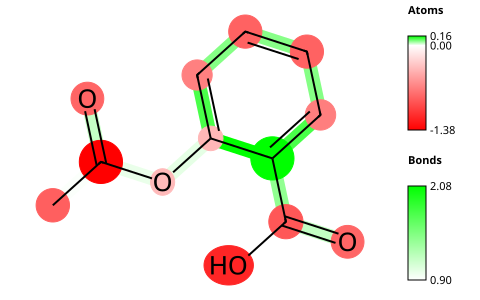

legend_units='raw' shown above; legend_units='normalized' (default) shown in the figure two cells up.


In [7]:
display(SVG(RDKitSVGVisualizer(legend_units="raw").visualize(aspirin, ig_explanation)))
print("legend_units='raw' shown above; legend_units='normalized' (default) shown in the figure two cells up.")

### Normalization strategies, actually rendered

`color_scale="combined"` was only *described* above using aspirin's own
numbers -- here it's actually rendered against the same `ig_explanation`
used throughout this notebook, so it can be compared directly against the
default (`"separate"`) figure several cells up.

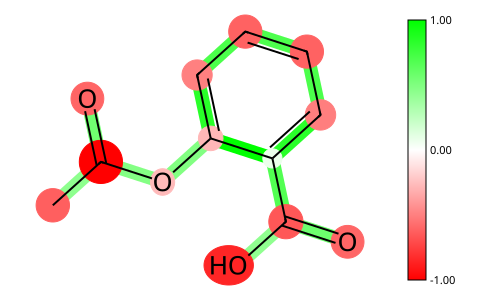

combined shared range: [-1.383, 2.077]
compare against the 'separate' figure above, where atoms and bonds each had their own range.


In [8]:
combined_svg = RDKitSVGVisualizer(color_scale="combined").visualize(aspirin, ig_explanation)
display(SVG(combined_svg))

all_scores = list(ig_explanation.atom_scores.values()) + list(ig_explanation.bond_scores.values())
print(f"combined shared range: [{min(all_scores):.3f}, {max(all_scores):.3f}]")
print("compare against the 'separate' figure above, where atoms and bonds each had their own range.")

### The minority-side deadband, made visible

`_MINORITY_DEADBAND_RATIO` (5%) keeps a score that's negligible relative to
the rest of its population from rendering as a solid red/green extreme just
because it sits on the smaller side of a straddling range. Aspirin's real IG
atom scores don't happen to trigger this branch -- the minority side here is
a healthy fraction of the majority side. Below is a synthetic explanation
built specifically to trigger it: the same scores as `ig_explanation`,
except one atom's score is nudged to a value that's genuinely
indistinguishable from zero relative to the rest.

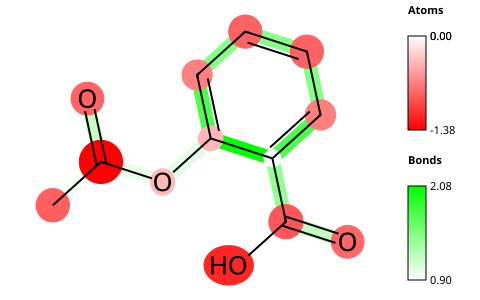

atom 9 score: 0.000277 -- renders near-white, not a color extreme.


In [9]:
majority_extreme = max(abs(v) for v in ig_explanation.atom_scores.values())
deadband_atom_scores = dict(ig_explanation.atom_scores)
deadband_atom_scores[9] = 0.0002 * majority_extreme  # ~0.02% of the majority side

deadband_explanation = Explanation(
    atom_scores=deadband_atom_scores,
    bond_scores=ig_explanation.bond_scores,
    metadata=ig_explanation.metadata,
)

display(SVG(RDKitSVGVisualizer(legend_units="raw").visualize(aspirin, deadband_explanation)))
print(f"atom 9 score: {deadband_atom_scores[9]:.6f} -- renders near-white, not a color extreme.")

### A fixed color scale across multiple molecules

Every figure above reused one molecule's own `ig_explanation`, so the
per-call auto-computed range was never actually a problem -- but comparing
*different* molecules side by side is exactly where it becomes misleading:
the same score can render a different color in each figure purely because
each molecule's other scores differ. `atom_range`/`bond_range` fix a shared
range across every `visualize()` call made on one `RDKitSVGVisualizer`
instance, so a reader can trust that matching colors mean matching scores.

-- auto-computed range per molecule (default) --


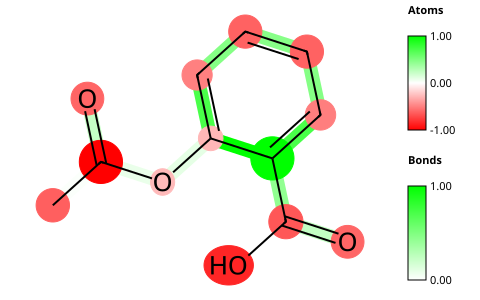

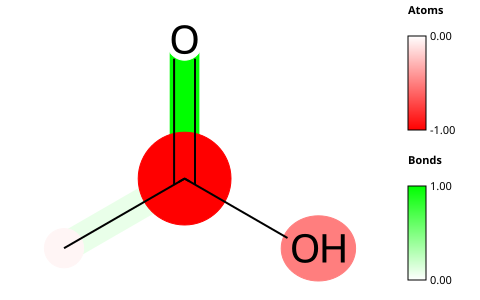


-- fixed atom_range=(-5.023759841918945, 0.15531182289123535), bond_range=(0.8992832899093628, 3.709595203399658) --


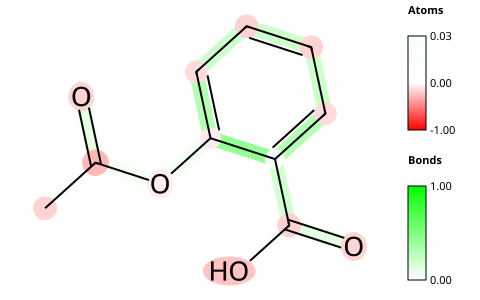

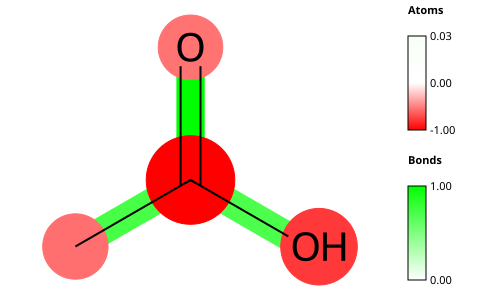

In [10]:
second_mol_name = "acetic_acid"
second_explanation = ig_explainer.explain(wrapper, mol_reps[second_mol_name])

print("-- auto-computed range per molecule (default) --")
auto_viz = RDKitSVGVisualizer()
display(SVG(auto_viz.visualize(aspirin, ig_explanation)))
display(SVG(auto_viz.visualize(mol_reps[second_mol_name], second_explanation)))

atom_pool = list(ig_explanation.atom_scores.values()) + list(second_explanation.atom_scores.values())
bond_pool = list(ig_explanation.bond_scores.values()) + list(second_explanation.bond_scores.values())
shared_atom_range = (min(atom_pool), max(atom_pool))
shared_bond_range = (min(bond_pool), max(bond_pool))

print(f"\n-- fixed atom_range={shared_atom_range}, bond_range={shared_bond_range} --")
fixed_viz = RDKitSVGVisualizer(atom_range=shared_atom_range, bond_range=shared_bond_range)
display(SVG(fixed_viz.visualize(aspirin, ig_explanation)))
display(SVG(fixed_viz.visualize(mol_reps[second_mol_name], second_explanation)))

## Explaining aspirin with Grad-CAM

`GradCAMExplainer` takes a different approach: instead of interpolating
along a path from a baseline (Integrated Gradients), it does a single
forward+backward pass and reads off one specific layer's activations,
weighted by how much that layer's output affects the prediction. Passing
both `target_layer` (node-indexed) and `edge_target_layer` (edge-indexed)
gets **both** atom and bond scores from the same pair of hooks — the
canonical Grad-CAM formula doesn't care whether the activation it's
applied to is indexed by node or by directed edge.


In [11]:
cam_explainer = GradCAMExplainer(
    target_layer=model.node_lin2,
    edge_target_layer=model.msg_lin2,
)
cam_explanation = cam_explainer.explain(wrapper, aspirin)


n_nonzero_atoms = sum(1 for v in cam_explanation.atom_scores.values() if v > 0)
print(f"atoms scored: {len(cam_explanation.atom_scores)} / {aspirin.mol.GetNumAtoms()}"
      f"  ({n_nonzero_atoms} nonzero)")
print(f"bonds scored: {len(cam_explanation.bond_scores)} / {aspirin.mol.GetNumBonds()}")
print(f"metadata: {cam_explanation.metadata}")


atoms scored: 13 / 13  (4 nonzero)
bonds scored: 13 / 13
metadata: {'predicted_value': 5.741733551025391, 'attribution': 'graph/direct'}


Grad-CAM's scores are **non-negative** (the final `ReLU` is part of the
algorithm's own definition, not a visualization choice), so the SVG above
renders white-to-green rather than red-to-green. It's normal — and not a
bug — for some atoms to come out exactly `0.0`: a small hidden dimension
gives the per-channel weights/activations less "room" to avoid cancelling
out for a given node. If every atom came out `0.0`, that would still be a
legitimate (if uninformative) result; here enough atoms are nonzero to
see real structure in the map.


### Atom-only attribution: `uses_edge_attr=False`

Everything above used `uses_edge_attr=True` on purpose, to get full bond
coverage — but that's only possible because `TinyMessagePassingGNN` was
built to consume `edge_attr` in every layer. `uses_edge_attr=False` is
`PyTorchGNNWrapper`'s actual **default**, and most PyG models — anything
using only node features, like `GCNConv`/`GINConv` — don't consume
`edge_attr` at all, so this is the common case, not an edge case.
`TinyMessagePassingGNN`'s `forward` has no default for its `edge_attr`
parameter, so it genuinely can't be called the `False` way — this section
trains a second, minimal model that only ever sees `(x, edge_index,
batch)`, on the exact same aromaticity task, to show what changes in the
XAI plumbing when a model like that is explained: `bond_scores` comes
back **empty (`{}`), not zero-filled** (`IntegratedGradientsExplainer` never infers bond attribution from data alone), and `RDKitSVGVisualizer` automatically collapses from a
stacked "Atoms"/"Bonds" legend down to a single atom-only color bar.

In [12]:
# A 2-layer node-only GNN -- never touches edge_attr, the common case
# `uses_edge_attr=False` targets (contrast with TinyMessagePassingGNN above,
# whose forward() requires edge_attr with no default).
class TinyNodeOnlyGNN(torch.nn.Module):
    def __init__(self, in_dim=2, hidden_dim=16, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.self_lin1 = torch.nn.Linear(in_dim, hidden_dim)
        self.neighbor_lin1 = torch.nn.Linear(in_dim, hidden_dim)
        self.self_lin2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.neighbor_lin2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.out_lin = torch.nn.Linear(hidden_dim, 1)

    @staticmethod
    def _layer(x, edge_index, self_lin, neighbor_lin):
        src, dst = edge_index[0], edge_index[1]
        agg = torch.zeros(x.shape[0], neighbor_lin.out_features, dtype=x.dtype)
        agg = agg.index_add(0, dst, neighbor_lin(x[src]))
        return (self_lin(x) + agg).relu()

    def forward(self, x, edge_index, batch):
        h = self._layer(x, edge_index, self.self_lin1, self.neighbor_lin1)
        h = self._layer(h, edge_index, self.self_lin2, self.neighbor_lin2)
        pooled = global_mean_pool(h, batch)
        return self.out_lin(pooled)


atom_only_model = TinyNodeOnlyGNN()
optimizer = torch.optim.Adam(atom_only_model.parameters(), lr=1e-2)
loss_fn = torch.nn.BCEWithLogitsLoss()

atom_only_model.train()
for epoch in range(150):
    optimizer.zero_grad()
    out = atom_only_model(train_batch.x, train_batch.edge_index, train_batch.batch)
    loss = loss_fn(out, label_tensor)
    loss.backward()
    optimizer.step()
print(f"epoch {epoch:3d}  loss={loss.item():.4f}  (final)")

epoch 149  loss=0.2356  (final)


In [13]:
atom_only_wrapper = PyTorchGNNWrapper(atom_only_model, uses_edge_attr=False)
atom_only_explanation = ig_explainer.explain(atom_only_wrapper, aspirin)

print("bond_scores:", atom_only_explanation.bond_scores)

bond_scores: {}


## Integrated Gradients vs. Grad-CAM

Both explainers now cover atoms *and* bonds, but they trade off
differently:

- **`IntegratedGradientsExplainer`** — signed scores (shows what pushes
  the prediction down as well as up), requires an interpolation loop
  (`n_steps` forward/backward passes), and works for any model consuming
  continuous features, node or edge.
- **`GradCAMExplainer`** — non-negative scores only, needs just a single
  forward+backward pass, and directly reflects one specific layer's
  learned representation — which also means bond-level attribution is
  opt-in and only possible for architectures (like this one) that expose
  an edge-indexed intermediate activation, unlike IG's edge attribution
  which works for any `edge_attr`-consuming model.

Neither is strictly "better" — which one (or both) to use depends on
whether signed contributions or a specific layer's learned features are
what you're trying to inspect.


## Same ring, opposite label: benzene vs. cyclohexane

The dataset section above called `cyclohexane` the molecule that makes this
task non-trivial — a six-membered carbon ring that is *not* aromatic, so no
model can succeed here by learning "has a ring". That also makes it the
cleanest available probe of what the explanation is keyed on, since benzene
and cyclohexane differ in one property and almost nothing else.

One catch makes this a numbers comparison rather than a visual one: both
molecules are perfectly symmetric, so every atom within each gets an
identical score and each renders as a single flat color. Whatever separates
them lives in the *magnitude*, not in any within-molecule pattern — which is
exactly what `atom_range` (above) and the dashboard's **shared** color scale
in **raw** units are for. A per-molecule auto-computed range rescales each
molecule to its own extremes and hides the entire difference.

In [14]:
ring_pair = {}
for name in ("benzene", "cyclohexane"):
    rep = mol_reps[name]
    ring_pair[name] = ig_explainer.explain(wrapper, rep)
    data = rep.pyg_data
    with torch.no_grad():
        prob = torch.sigmoid(model(
            data.x,
            data.edge_index,
            data.edge_attr,
            torch.zeros(data.x.shape[0], dtype=torch.long),
        )).item()
    scores = [ring_pair[name].atom_scores[i] for i in range(rep.mol.GetNumAtoms())]
    print(f"{name:12s} aromatic={bool(labels[name])}  P(aromatic)={prob:.3f}")
    print(f"    atom scores: {[round(s, 3) for s in scores]}")
    print(f"    spread within the molecule: {max(scores) - min(scores):.1e}")

per_atom_gap = ring_pair["benzene"].atom_scores[0] - ring_pair["cyclohexane"].atom_scores[0]
print(f"\nper-atom gap between the two rings: {per_atom_gap:+.3f}")
print("(visible only under a shared scale -- each molecule alone is one flat color)")

benzene      aromatic=True  P(aromatic)=0.995
    atom scores: [-1.892, -1.892, -1.892, -1.892, -1.892, -1.892]
    spread within the molecule: 0.0e+00
cyclohexane  aromatic=False  P(aromatic)=0.018
    atom scores: [-2.347, -2.347, -2.347, -2.347, -2.347, -2.347]
    spread within the molecule: 0.0e+00

per-atom gap between the two rings: +0.455
(visible only under a shared scale -- each molecule alone is one flat color)


## Does the input featurization change the explanation?

`generate_graph_representation` takes `atom_featurizer` and `bond_featurizer`
as **required** arguments, with no shipped default anywhere in the package.
This section shows what that requirement is protecting against.

`tree_demo.ipynb` makes the same point from the other side, comparing Morgan
fingerprints against MACCS keys: two schemes, two models, two different
explanations of one molecule. The graph path's version of that choice is the
featurizer itself.

The comparison below adds one feature — `atom.IsInRing()` — to the existing
`[atomic number, degree]`. Ring membership is safe to expose in a way
`GetIsAromatic()` is not (see the note under the dataset): `cyclohexane` has
rings and is not aromatic, so the feature is genuinely informative without
being the label in disguise.

In [15]:
def ring_atom_featurizer(atom):
    """[atomic number, degree, ring membership] -- one feature more than above."""
    return [atom.GetAtomicNum(), atom.GetDegree(), float(atom.IsInRing())]


ring_reps = {
    name: generate_graph_representation(smiles, ring_atom_featurizer, bond_featurizer)
    for name, smiles in TRAIN_SMILES.items()
}
ring_batch = Batch.from_data_list([ring_reps[name].pyg_data for name in names])

ring_model = TinyMessagePassingGNN(in_dim=3)
optimizer = torch.optim.Adam(ring_model.parameters(), lr=1e-2)
loss_fn = torch.nn.BCEWithLogitsLoss()

ring_model.train()
for epoch in range(150):
    optimizer.zero_grad()
    out = ring_model(ring_batch.x, ring_batch.edge_index, ring_batch.edge_attr, ring_batch.batch)
    loss = loss_fn(out, label_tensor)
    loss.backward()
    optimizer.step()

ring_model.eval()
with torch.no_grad():
    ring_probs = torch.sigmoid(
        ring_model(ring_batch.x, ring_batch.edge_index, ring_batch.edge_attr, ring_batch.batch)
    )
accuracy = ((ring_probs > 0.5).float() == label_tensor).float().mean().item()
print(f"[Z, degree, in_ring]  final loss={loss.item():.4f}  accuracy={accuracy:.2f}")

[Z, degree, in_ring]  final loss=0.0026  accuracy=1.00


In [16]:
ring_wrapper = PyTorchGNNWrapper(ring_model, uses_edge_attr=True)
ring_aspirin_explanation = ig_explainer.explain(ring_wrapper, ring_reps["aspirin"])

aspirin_mol = aspirin.mol
n_atoms = aspirin_mol.GetNumAtoms()
base_scores = [ig_explanation.atom_scores[i] for i in range(n_atoms)]
ring_scores = [ring_aspirin_explanation.atom_scores[i] for i in range(n_atoms)]

print(f"{'atom':>4} {'sym':>4} {'arom':>6} {'[Z,deg]':>10} {'+in_ring':>10}")
for i in range(n_atoms):
    atom = aspirin_mol.GetAtomWithIdx(i)
    print(f"{i:>4} {atom.GetSymbol():>4} {str(atom.GetIsAromatic()):>6} "
          f"{base_scores[i]:>+10.4f} {ring_scores[i]:>+10.4f}")

def average_ranks(values):
    """Ranks with ties averaged. Spearman's rho is Pearson's r on these."""
    order = sorted(range(len(values)), key=lambda i: values[i])
    ranks = [0.0] * len(values)
    start = 0
    while start < len(order):
        stop = start
        while stop + 1 < len(order) and values[order[stop + 1]] == values[order[start]]:
            stop += 1
        for position in range(start, stop + 1):
            ranks[order[position]] = (start + stop) / 2.0
        start = stop + 1
    return ranks


paired = torch.tensor([base_scores, ring_scores])
ranked = torch.tensor([average_ranks(base_scores), average_ranks(ring_scores)])
print(f"\nPearson  (are the values alike?):   "
      f"{torch.corrcoef(paired)[0, 1].item():+.3f}")
print(f"Spearman (is the ordering alike?): "
      f"{torch.corrcoef(ranked)[0, 1].item():+.3f}")

top3 = lambda scores: sorted(range(n_atoms), key=lambda i: -scores[i])[:3]
print("\ntop-3 atoms  [Z, degree]:", top3(base_scores), " + in_ring:", top3(ring_scores))
print("atoms whose sign flips:  ",
      [i for i in range(n_atoms) if (base_scores[i] > 0) != (ring_scores[i] > 0)])

aromatic_atoms = [i for i in range(n_atoms) if aspirin_mol.GetAtomWithIdx(i).GetIsAromatic()]
for tag, scores in (("[Z, degree]", base_scores), ("+ in_ring", ring_scores)):
    share = sum(abs(scores[i]) for i in aromatic_atoms) / sum(abs(s) for s in scores)
    print(f"  {tag:<13} share of total |score| on the "
          f"{len(aromatic_atoms)} aromatic atoms: {share:.1%}")

atom  sym   arom    [Z,deg]   +in_ring
   0    C  False    -0.8637    -1.5683
   1    C  False    -1.3829    -1.3592
   2    O  False    -0.8314    -2.1878
   3    O  False    -0.3698    -1.7225
   4    C   True    -0.3898    +0.6336
   5    C   True    -0.6841    -1.4695
   6    C   True    -0.8497    -1.7709
   7    C   True    -0.8493    -1.7709
   8    C   True    -0.6963    -1.4677
   9    C   True    +0.1553    +1.0906
  10    C  False    -0.9061    -1.4250
  11    O  False    -0.8254    -2.2032
  12    O  False    -1.1786    -1.3137

Pearson  (are the values alike?):   +0.660
Spearman (is the ordering alike?): +0.052

top-3 atoms  [Z, degree]: [9, 3, 4]  + in_ring: [9, 4, 12]
atoms whose sign flips:   [4]
  [Z, degree]   share of total |score| on the 6 aromatic atoms: 36.3%
  + in_ring     share of total |score| on the 6 aromatic atoms: 41.1%


Both models solve the task perfectly, and the second is not better in any way
a user would notice from outside. What changed is the *explanation* — and the
two correlations tell opposite halves of that story.

Pearson is a respectable ~0.66: the attributions have a broadly similar shape
and scale. Spearman is ~0.05, meaning **the ordering of the atoms is
essentially unrelated between the two**. If the question you brought to the
figure was "which atoms matter most here", the two featurizations answer it
differently while looking equally plausible. Only one atom actually changes
sign, and the share of attribution landing on the aromatic ring barely moves
(36% to 41%) — so handing the model a feature a chemist would call obviously
relevant did **not** concentrate the explanation onto the ring.

Worth setting that against `tree_demo.ipynb`'s Morgan-vs-MACCS section, which
runs the same test on the other paradigm and gets the *opposite* result: two
bit vocabularies with no index in common still agreed on the ranking
(Spearman ~0.69). Changing the fingerprint scheme there preserved the story;
changing the graph featurizer here did not. Both are tiny models on a dozen
molecules, so neither is evidence about GNNs in general — the transferable
part is that the question is worth asking of your own model, and that VisXAI
gives you the numbers to ask it.

That is the point the architecture is built around: an explanation is a
property of one specific model and the features it was trained on — not of
the molecule. VisXAI has no way to check that the featurizer it is handed
matches the one a model was trained with, and a mismatch does not raise. It
quietly returns a different, equally confident-looking picture. Hence
required featurizer arguments rather than a convenient default.

## Interactive exploration

Everything above renders a **static** SVG. The same explanations can be
explored interactively instead, with no re-computation: `ExplanationDashboard`
re-renders explanations that already exist, and never re-runs an explainer.

Each panel is a `MoleculeHoverWidget` — the structure paired with an
XSMILES-style SMILES strip, cross-highlighting as the cursor moves, with a
readout giving the raw score, the normalized value driving the color, and
**how that score was assembled**.

Two things to know before running this:

- It needs a **live kernel** and the `viz` extra (`pip install -e ".[viz]"`,
  which brings `ipywidgets>=8` and `anywidget`). A rendered copy on GitHub or
  nbviewer shows a blank area where the widget would be.
- Nothing here is paradigm-specific. The dashboard only touches
  `MoleculeRepresentation` and `Explanation`, so the code below is the same in
  all three demo notebooks.

In [17]:
from visxai.visualizers.interactive import ExplanationDashboard

results = {
    "aspirin": (aspirin, {
        "Integrated Gradients": ig_explanation,
        "Grad-CAM": cam_explanation,
        "IG (atoms only)": atom_only_explanation,
    }),
    # Same six-membered ring, opposite label -- the contrast is in the
    # magnitudes, so read these two under a shared scale in raw units.
    "benzene": (mol_reps["benzene"], {"Integrated Gradients": ring_pair["benzene"]}),
    "cyclohexane": (mol_reps["cyclohexane"], {"Integrated Gradients": ring_pair["cyclohexane"]}),
    # A different input feature scheme entirely -- same molecule, same
    # explainer, different features underneath.
    "aspirin (+in_ring)": (ring_reps["aspirin"], {"Integrated Gradients": ring_aspirin_explanation}),
}

dashboard = ExplanationDashboard.from_results(results, width=380, height=300)
print("molecules: ", dashboard.molecules)
print("explainers:", dashboard.explainers)

molecules:  ['aspirin', 'benzene', 'cyclohexane', 'aspirin (+in_ring)']
explainers: ['Integrated Gradients', 'Grad-CAM', 'IG (atoms only)']


### Why there is no provenance clause here

On the other two paths the readout ends with a clause explaining how a score
was assembled — `"1 bit, split 6 ways"`, `"1 token, in full"`. On the graph
path it is absent, and that is deliberate rather than an oversight.

Node *i* **is** atom *i*. There is no redistribution step to describe: the
attribution a node receives is the score the atom gets. Recording a
one-entry breakdown per atom would add noise without adding information, so
these explainers record the convention (`metadata["attribution"]`) and leave
the per-element provenance empty.

This is also the only path where `sum(atom_scores) + sum(bond_scores)` lines
up with the model's own prediction difference, for the same reason — nothing
is duplicated onto several elements or dropped along the way.

In [18]:
print("attribution:", ig_explanation.metadata["attribution"])
print("atom_provenance recorded:", bool(ig_explanation.atom_provenance))
print("bond_provenance recorded:", bool(ig_explanation.bond_provenance))
print(f'\natoms scored: {len(ig_explanation.atom_scores)} of '
      f'{aspirin.mol.GetNumAtoms()}')
print(f'bonds scored: {len(ig_explanation.bond_scores)} of '
      f'{aspirin.mol.GetNumBonds()}   <- full coverage, unlike the sequence path')

attribution: graph/direct
atom_provenance recorded: False
bond_provenance recorded: False

atoms scored: 13 of 13
bonds scored: 13 of 13   <- full coverage, unlike the sequence path


In [19]:
dashboard.display()

In [20]:
# Sanity check, so this section is verifiable without a browser.
#
# nbclient executes `display(widget)` happily whether or not anything
# actually renders, so executing the notebook proves very little on its own
# (the same reason dashboard_demo.ipynb carries a cell like this). These
# asserts use only the public API -- render_svg() returns the same SVG a
# panel shows, independent of the widget tree.
import re


def strip_ids(svg):
    """RDKit gives every render a fresh random gradient id."""
    return re.sub(r'visxaiLegendGradient\w*', 'GRAD', svg)


rendered = {
    (mol, exp): dashboard.render_svg(mol, exp)
    for mol in dashboard.molecules
    for exp in dashboard.explainers
    if dashboard.render_svg(mol, exp) is not None
}
assert rendered, "no registered pair rendered"
for (mol, exp), svg in rendered.items():
    assert svg.startswith("<svg") or "<svg" in svg, (mol, exp)
    assert "<title>" in svg, f"tooltips missing for {mol}/{exp}"

print(f"rendered {len(rendered)} panel(s) across "
      f"{len(dashboard.molecules)} molecule(s) x {len(dashboard.explainers)} explainer(s)")

# The provenance clause reaches the tooltip text itself.
clauses = sorted({
    m.group(1)
    for svg in rendered.values()
    for m in re.finditer(r'<title>[^<]*\u2014 ([^<]+)</title>', svg)
})
print("provenance clauses seen:", clauses[:3] or "(none recorded)")

rendered 6 panel(s) across 4 molecule(s) x 3 explainer(s)
provenance clauses seen: (none recorded)


## Next steps

All three planned paradigms (tree/tabular, sequence, graph) now have a
working end-to-end demo, as does the interactive comparison layer
(`dashboard_demo.ipynb`), and `logp_usecase.ipynb` checks the mapped
scores against a known per-atom decomposition. What is still missing:

- `visxai/visualizers/py3dmol_3d.py` — 3D visualization; everything here
  is 2D (`rdkit.Chem.Draw.rdMolDraw2D`).
- **Protein-centered visualization**, the stated next direction. The
  mapping problem reappears there in a harder form — residues sit above
  atoms with no small-molecule analogue, and sequence-to-structure
  alignment has gaps and unresolved regions that SMILES character spans
  never present. The visualizer's SVG-returning contract is the first
  thing that would have to change.
- Saving a *live* interactive dashboard to a file. `visualize()` returns
  an SVG string you can write yourself, but there is no export path for a
  live widget.